In [45]:
import numpy as np
import os
import matplotlib.pyplot as plt

def hist(val, bins=None, log=False):
    val = np.asarray(val)
    if bins is None:
        n = int(np.sqrt(len(val)))
        if log:
            bins = np.logspace(
                min(np.log10(val[val > 0])),
                max(np.log10(val[val > 0])),
                n
            )
        else:
            bins = np.linspace(
                min(val),
                max(val),
                n
            )
    p_val, edges = np.histogram(
        val,
        bins,
        density=True
    )
    return p_val, (edges[1:] + edges[:-1]) / 2

root = 'data'

z_vertex_small = np.load(os.path.join(root, 'z_vertex_small.npz'))
mu_vertex_small = np.load(os.path.join(root, 'mu_vertex_small.npz'))
z_clump_small = np.load(os.path.join(root, 'z_clump_small.npz'))
mu_clump_small = np.load(os.path.join(root, 'mu_clump_small.npz'))

z_vertex_large = np.load(os.path.join(root, 'z_vertex_large.npz'))
mu_vertex_large = np.load(os.path.join(root, 'mu_vertex_large.npz'))
z_clump_large = np.load(os.path.join(root, 'z_clump_large.npz'))
mu_clump_large = np.load(os.path.join(root, 'mu_clump_large.npz'))

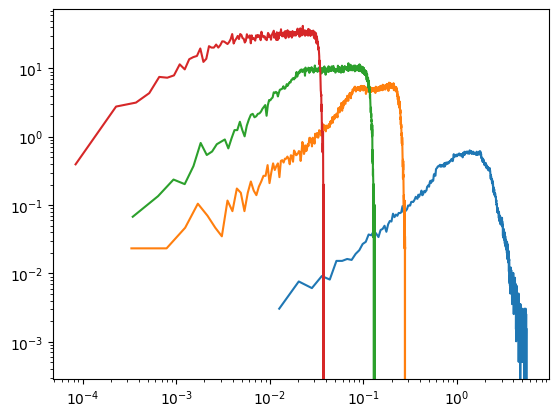

In [46]:
means = []
stds = []
maxs = []
arads = []
nvs = []

for nv_arad in np.unique(np.column_stack((mu_vertex_large['nv'], mu_vertex_large['arad'])), axis=0):
    nv, arad = nv_arad

    ds = mu_vertex_large
    mask = (ds['nv'] == nv) & (ds['arad'] == arad)
    p, x = hist(ds['val'][mask])
    plt.plot(x, p)

    means.append(np.mean(ds['val'][mask]))
    stds.append(np.std(ds['val'][mask]))
    maxs.append(np.max(ds['val'][mask]))
    arads.append(arad)
    nvs.append(nv)

plt.xscale('log')
plt.yscale('log')

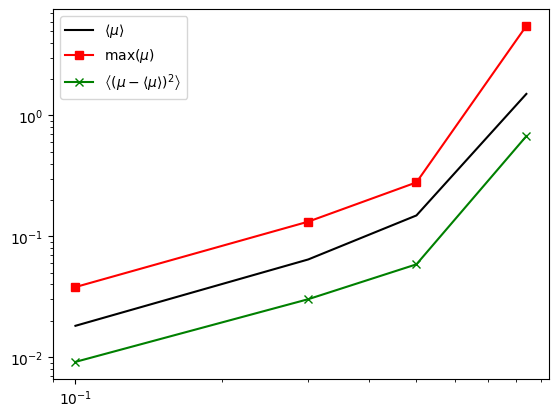

In [47]:
plt.plot(2 * (0.5 - np.array(arads)), means,  c='k', label=r'$\langle \mu \rangle$')
plt.plot(2 * (0.5 - np.array(arads)), maxs, c='r', marker='s', label=r'$\max(\mu)$')
plt.plot(2 * (0.5 - np.array(arads)), stds, c='g', marker='x', label=r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$')
plt.legend()
plt.xscale('log')
plt.yscale('log')

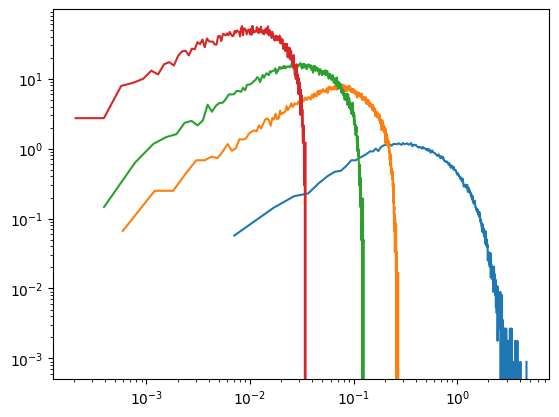

In [48]:
means = []
stds = []
maxs = []
arads = []
nvs = []

for nv_arad in np.unique(np.column_stack((mu_clump_large['nv'], mu_clump_large['arad'])), axis=0):
    nv, arad = nv_arad

    ds = mu_clump_large
    mask = (ds['nv'] == nv) & (ds['arad'] == arad)
    p, x = hist(ds['val'][mask])
    plt.plot(x, p)

    means.append(np.mean(ds['val'][mask]))
    stds.append(np.std(ds['val'][mask]))
    maxs.append(np.max(ds['val'][mask]))
    arads.append(arad)
    nvs.append(nv)

plt.xscale('log')
plt.yscale('log')

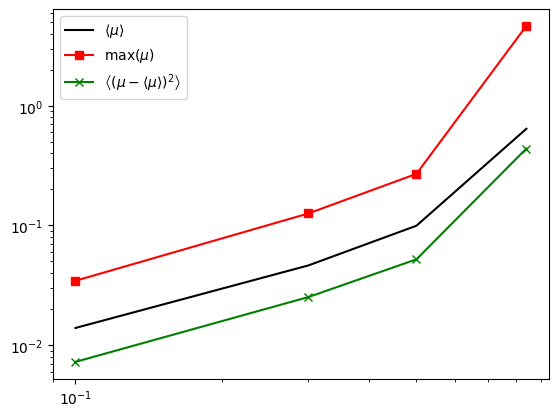

In [49]:
plt.plot(2 * (0.5 - np.array(arads)), means,  c='k', label=r'$\langle \mu \rangle$')
plt.plot(2 * (0.5 - np.array(arads)), maxs, c='r', marker='s', label=r'$\max(\mu)$')
plt.plot(2 * (0.5 - np.array(arads)), stds, c='g', marker='x', label=r'$\left \langle (\mu - \langle \mu \rangle)^2 \right \rangle$')
plt.legend()
plt.xscale('log')
plt.yscale('log')